Interpretation of two best models for every metric. Boosting and not boosting.

# Libraries

In [18]:
import os
import shutil
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import shap
from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score

In [19]:
RANDOM_STATE = 42

In [20]:
# train/test split
import sys
sys.path.insert(1, '../utils_functionality/split_utils/')
from split_tools import get_train_test

In [21]:
# dict with num features
sys.path.insert(1, '../utils_functionality/models/')
from modelling2_hyperparams import dict_num_features

# Choosing models 

In [22]:
df_metrics = pd.read_excel(r'..\results\metrics_modelling2_filtered_optuna.xlsx', index_col=[0])
dict_best_models = {}

## Splashing

In [23]:
df_metrics[df_metrics['target']=='splashing'].sort_values(by='f1', ascending=False).head(5)

,dataset,target,model,accuracy,f1,precision,recall,roc_auc,optuna_flg
60,df_modelling_no_multicollinearity_pf,splashing,svc_smote_splashing_ordenc,0.920000,0.938776,0.9200,0.958333,0.905093,1.0
56,df_modelling_dimensionless_pf,splashing,svc_smote_splashing_onehot,0.920000,0.938776,0.9200,0.958333,0.905093,1.0
55,df_modelling_dimensionless,splashing,svc_smote_splashing_onehot,0.920000,0.938776,0.9200,0.958333,0.905093,1.0
59,df_modelling_dimensionless,splashing,svc_smote_splashing_ordenc,0.920000,0.937500,0.9375,0.937500,0.913194,1.0
50,df_modelling_no_multicollinearity_pf,splashing,catboostclassifier_smote_splashing,0.893333,0.918367,0.9000,0.937500,0.876157,1.0


Best sklearn model:

In [24]:
df_metrics.iloc[60]

dataset       df_modelling_no_multicollinearity_pf
target                                   splashing
model                   svc_smote_splashing_ordenc
accuracy                                      0.92
f1                                        0.938776
precision                                     0.92
recall                                    0.958333
roc_auc                                   0.905093
optuna_flg                                     1.0
Name: 60, dtype: object

Best boosting model

In [25]:
df_metrics.iloc[50]

dataset       df_modelling_no_multicollinearity_pf
target                                   splashing
model           catboostclassifier_smote_splashing
accuracy                                  0.893333
f1                                        0.918367
precision                                      0.9
recall                                      0.9375
roc_auc                                   0.876157
optuna_flg                                     1.0
Name: 50, dtype: object

In [26]:
dict_best_models['splashing'] = {
    'sklearn': df_metrics.iloc[60],
    'boosting': df_metrics.iloc[50]}

## Net impact

In [27]:
df_metrics[df_metrics['target']=='net_impact'].sort_values(by='f1', ascending=False).head(3)

,dataset,target,model,accuracy,f1,precision,recall,roc_auc,optuna_flg
0,df_modelling_dimensionless,net_impact,catboostclassifier_net_impact,0.946667,0.9,0.9,0.9,0.931818,NaN
1,df_modelling_dimensionless_pf,net_impact,catboostclassifier_net_impact,0.946667,0.9,0.9,0.9,0.931818,NaN
38,df_modelling_no_multicollinearity_pf,net_impact,kneighborsclassifier_net_impact_onehot,0.946667,0.9,0.9,0.9,0.931818,1.0


Best sklearn model:

In [28]:
df_metrics.iloc[38]

dataset         df_modelling_no_multicollinearity_pf
target                                    net_impact
model         kneighborsclassifier_net_impact_onehot
accuracy                                    0.946667
f1                                               0.9
precision                                        0.9
recall                                           0.9
roc_auc                                     0.931818
optuna_flg                                       1.0
Name: 38, dtype: object

Best boosting model

In [29]:
df_metrics.iloc[0]

dataset          df_modelling_dimensionless
target                           net_impact
model         catboostclassifier_net_impact
accuracy                           0.946667
f1                                      0.9
precision                               0.9
recall                                  0.9
roc_auc                            0.931818
optuna_flg                              NaN
Name: 0, dtype: object

In [30]:
dict_best_models['net_impact'] = {
    'sklearn': df_metrics.iloc[38],
    'boosting': df_metrics.iloc[0]}

# Model interpretation

In [31]:
path_interpretations = Path('../results/best_models_interpretations_modelling_2/')
if not os.path.exists(path_interpretations): os.makedirs(path_interpretations)
path_best_models = Path('../results/best_models_selected_modelling_2/')
if not os.path.exists(path_best_models): os.makedirs(path_best_models)

## Splashing

### Sklearn

In [32]:
target = 'splashing'
train, test = get_train_test(
    dataset_filename=dict_best_models[target]['sklearn']['dataset'],
    target=target)
train = train[dict_num_features[dict_best_models[target]['sklearn']['dataset']]+['wettability']+[target]]
test = test[dict_num_features[dict_best_models[target]['sklearn']['dataset']]+['wettability']+[target]]

In [33]:
dict_best_models[target]['sklearn']

dataset       df_modelling_no_multicollinearity_pf
target                                   splashing
model                   svc_smote_splashing_ordenc
accuracy                                      0.92
f1                                        0.938776
precision                                     0.92
recall                                    0.958333
roc_auc                                   0.905093
optuna_flg                                     1.0
Name: 60, dtype: object

In [39]:
path_pipeline = r'..\results\best_models_modelling_2\svc_smote_splashing_ordenc_df_modelling_no_multicollinearity_pf_splashing.pkl'
pipeline = joblib.load(path_pipeline)

In [19]:
shutil.copy(path_pipeline, path_best_models / 'splashing_sklearn.pkl')

WindowsPath('../results/best_models_selected_modelling_2/splashing_sklearn.pkl')

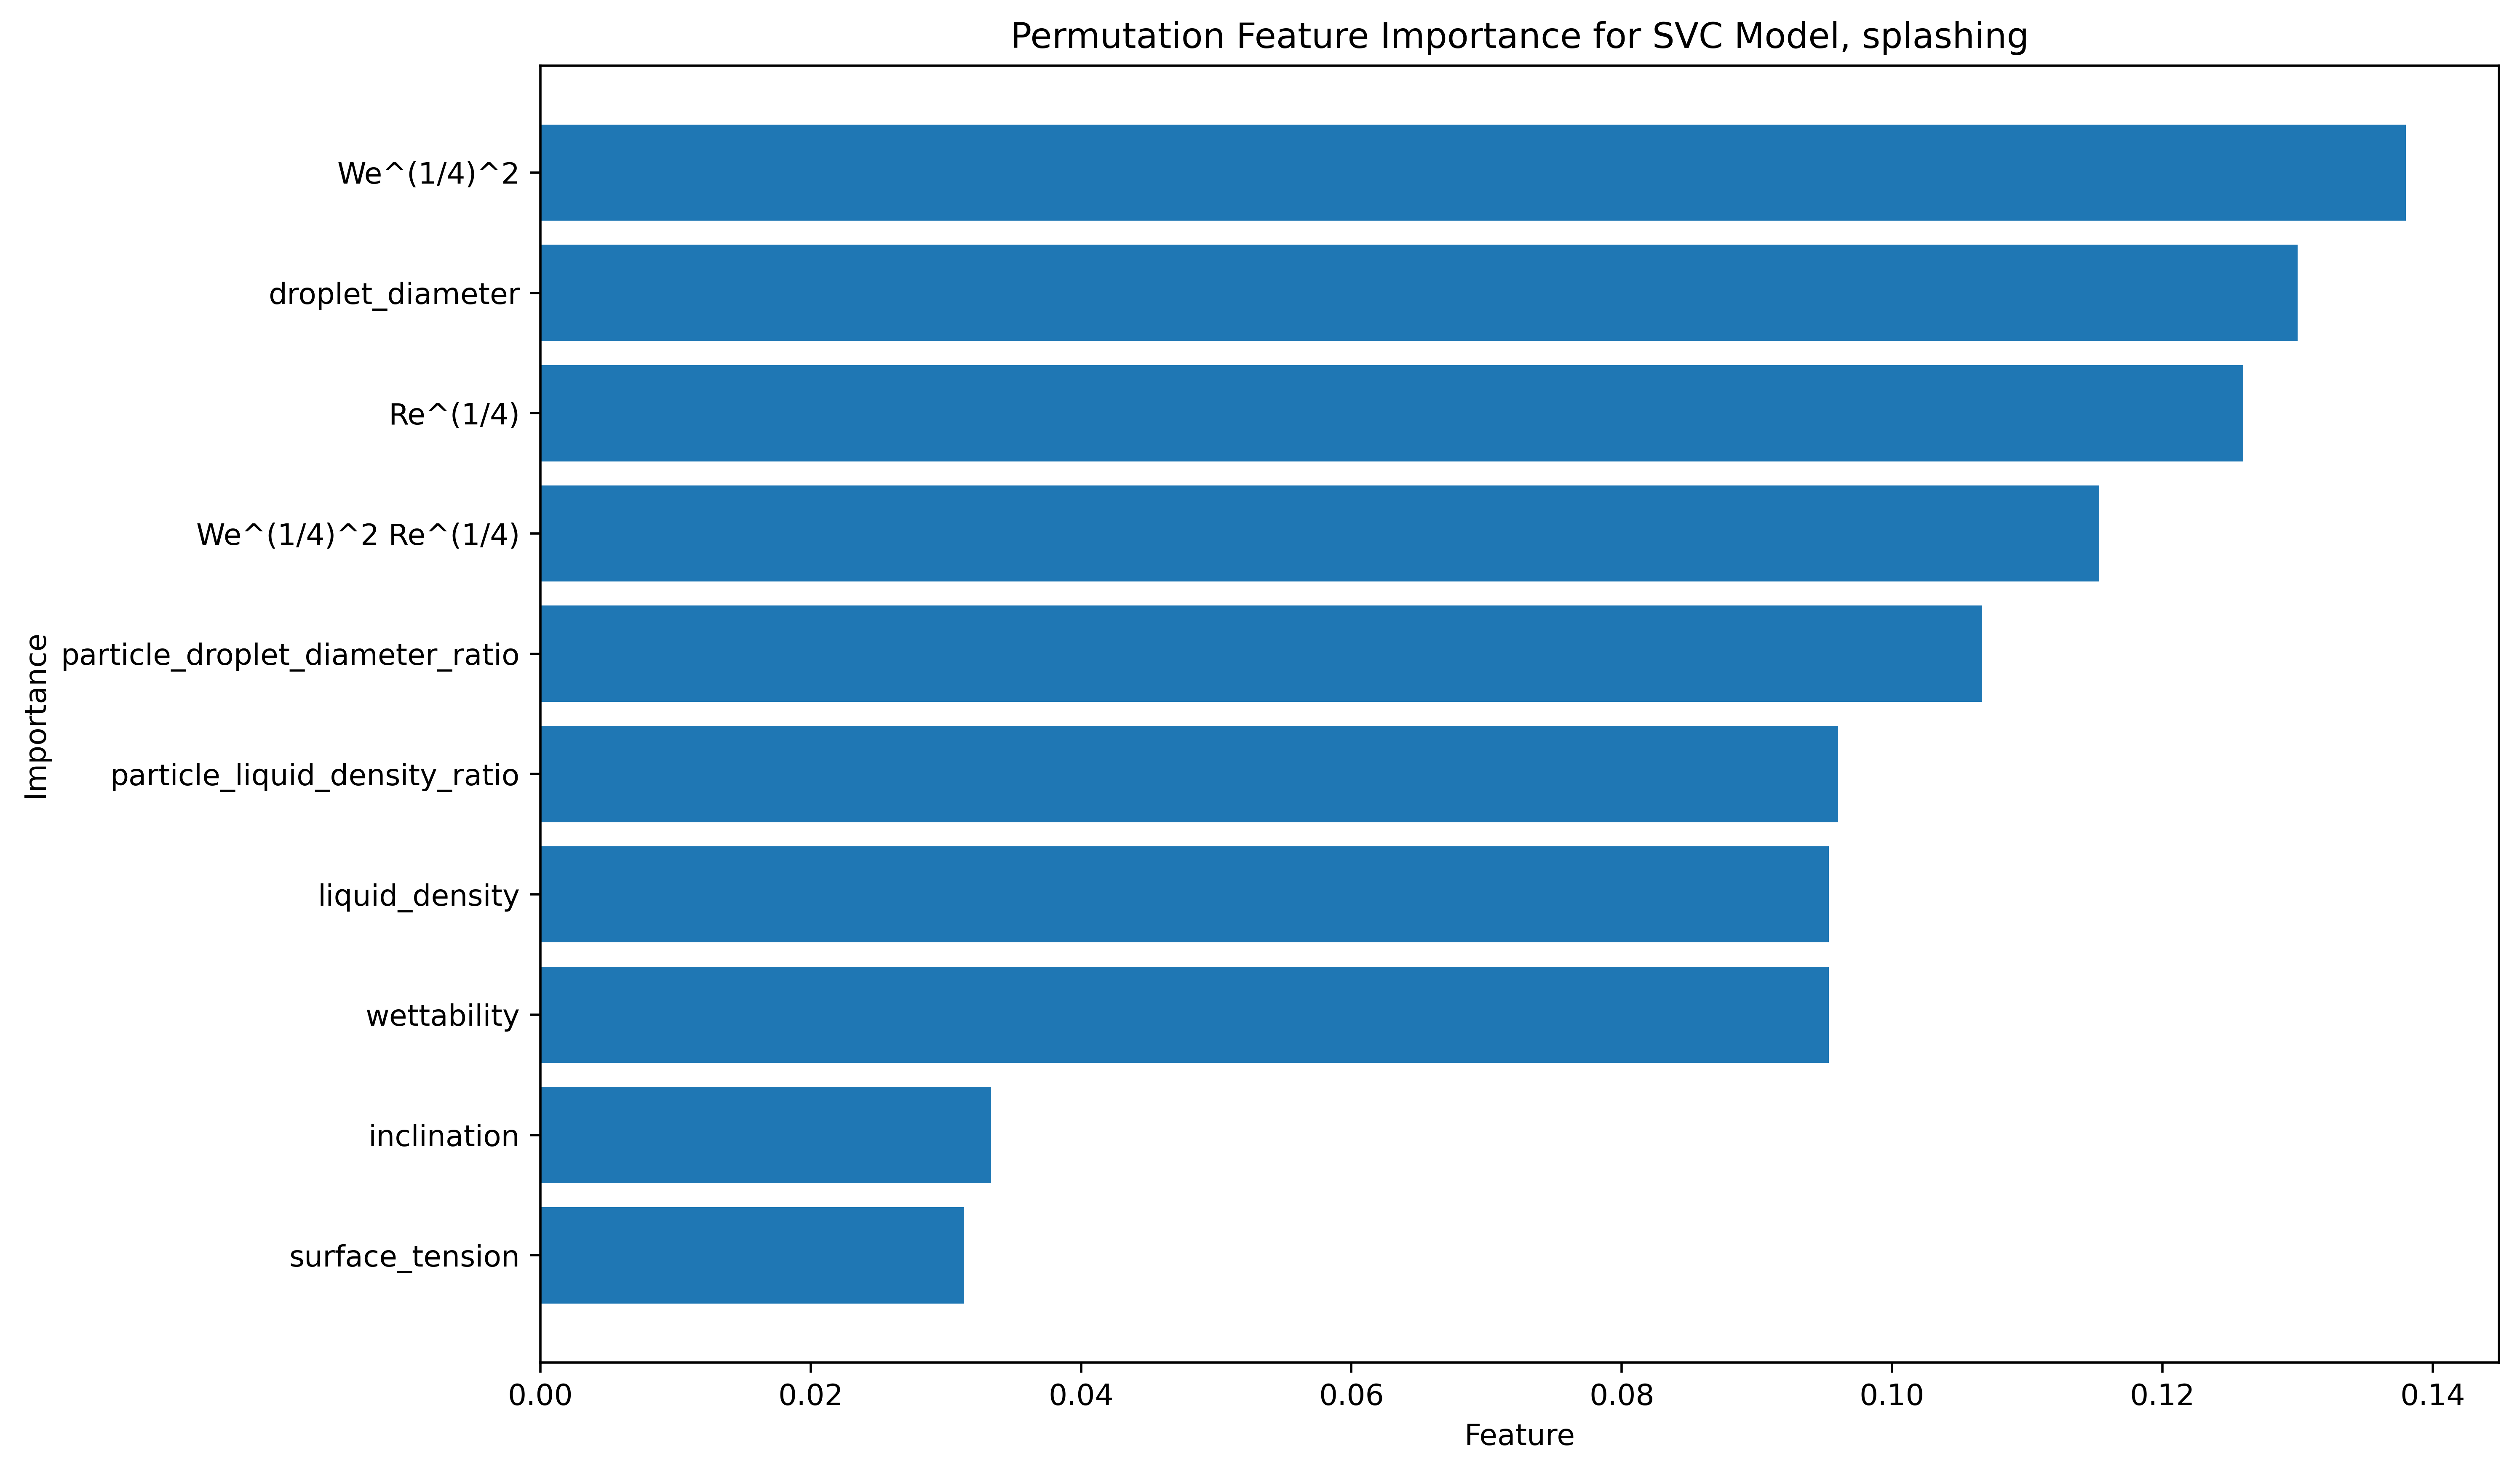

In [20]:
column_transformer = pipeline.steps[0][1].fit(train.drop(columns=[target]))
result = permutation_importance(
    estimator=pipeline.steps[1][1], 
    X=column_transformer.transform(test.drop(columns=[target])), 
    y=test[target], 
    n_repeats=20, 
    random_state=RANDOM_STATE)

importances = result.importances_mean
feature_names = column_transformer.get_feature_names_out()
feature_names = [x.split('__')[1] for x in feature_names]

df_permut_feature_importance = pd.DataFrame(
    {'Feature name': feature_names, 
     'Feature importance': importances}
).sort_values(by='Feature importance')
plt.figure(figsize=(12, 8),dpi=500)
plt.barh(
    y=df_permut_feature_importance['Feature name'],
    width=df_permut_feature_importance['Feature importance']
    )
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title(f'Permutation Feature Importance for SVC Model, {target}')
plt.savefig(path_interpretations / f'best_sklearn_{target}.pdf', bbox_inches='tight')
plt.show()

### Boosting models

In [21]:
dict_best_models['splashing']['boosting']

dataset       df_modelling_no_multicollinearity_pf
target                                   splashing
model           catboostclassifier_smote_splashing
accuracy                                  0.893333
f1                                        0.918367
precision                                      0.9
recall                                      0.9375
roc_auc                                   0.876157
optuna_flg                                     1.0
Name: 50, dtype: object

In [22]:
path_pipeline = r'..\results\best_models_modelling_2\catboostclassifier_smote_splashing_df_modelling_no_multicollinearity_pf_splashing.pkl'
pipeline = joblib.load(path_pipeline)

In [23]:
shutil.copy(path_pipeline, path_best_models / 'splashing_boosting.pkl')

WindowsPath('../results/best_models_selected_modelling_2/splashing_boosting.pkl')

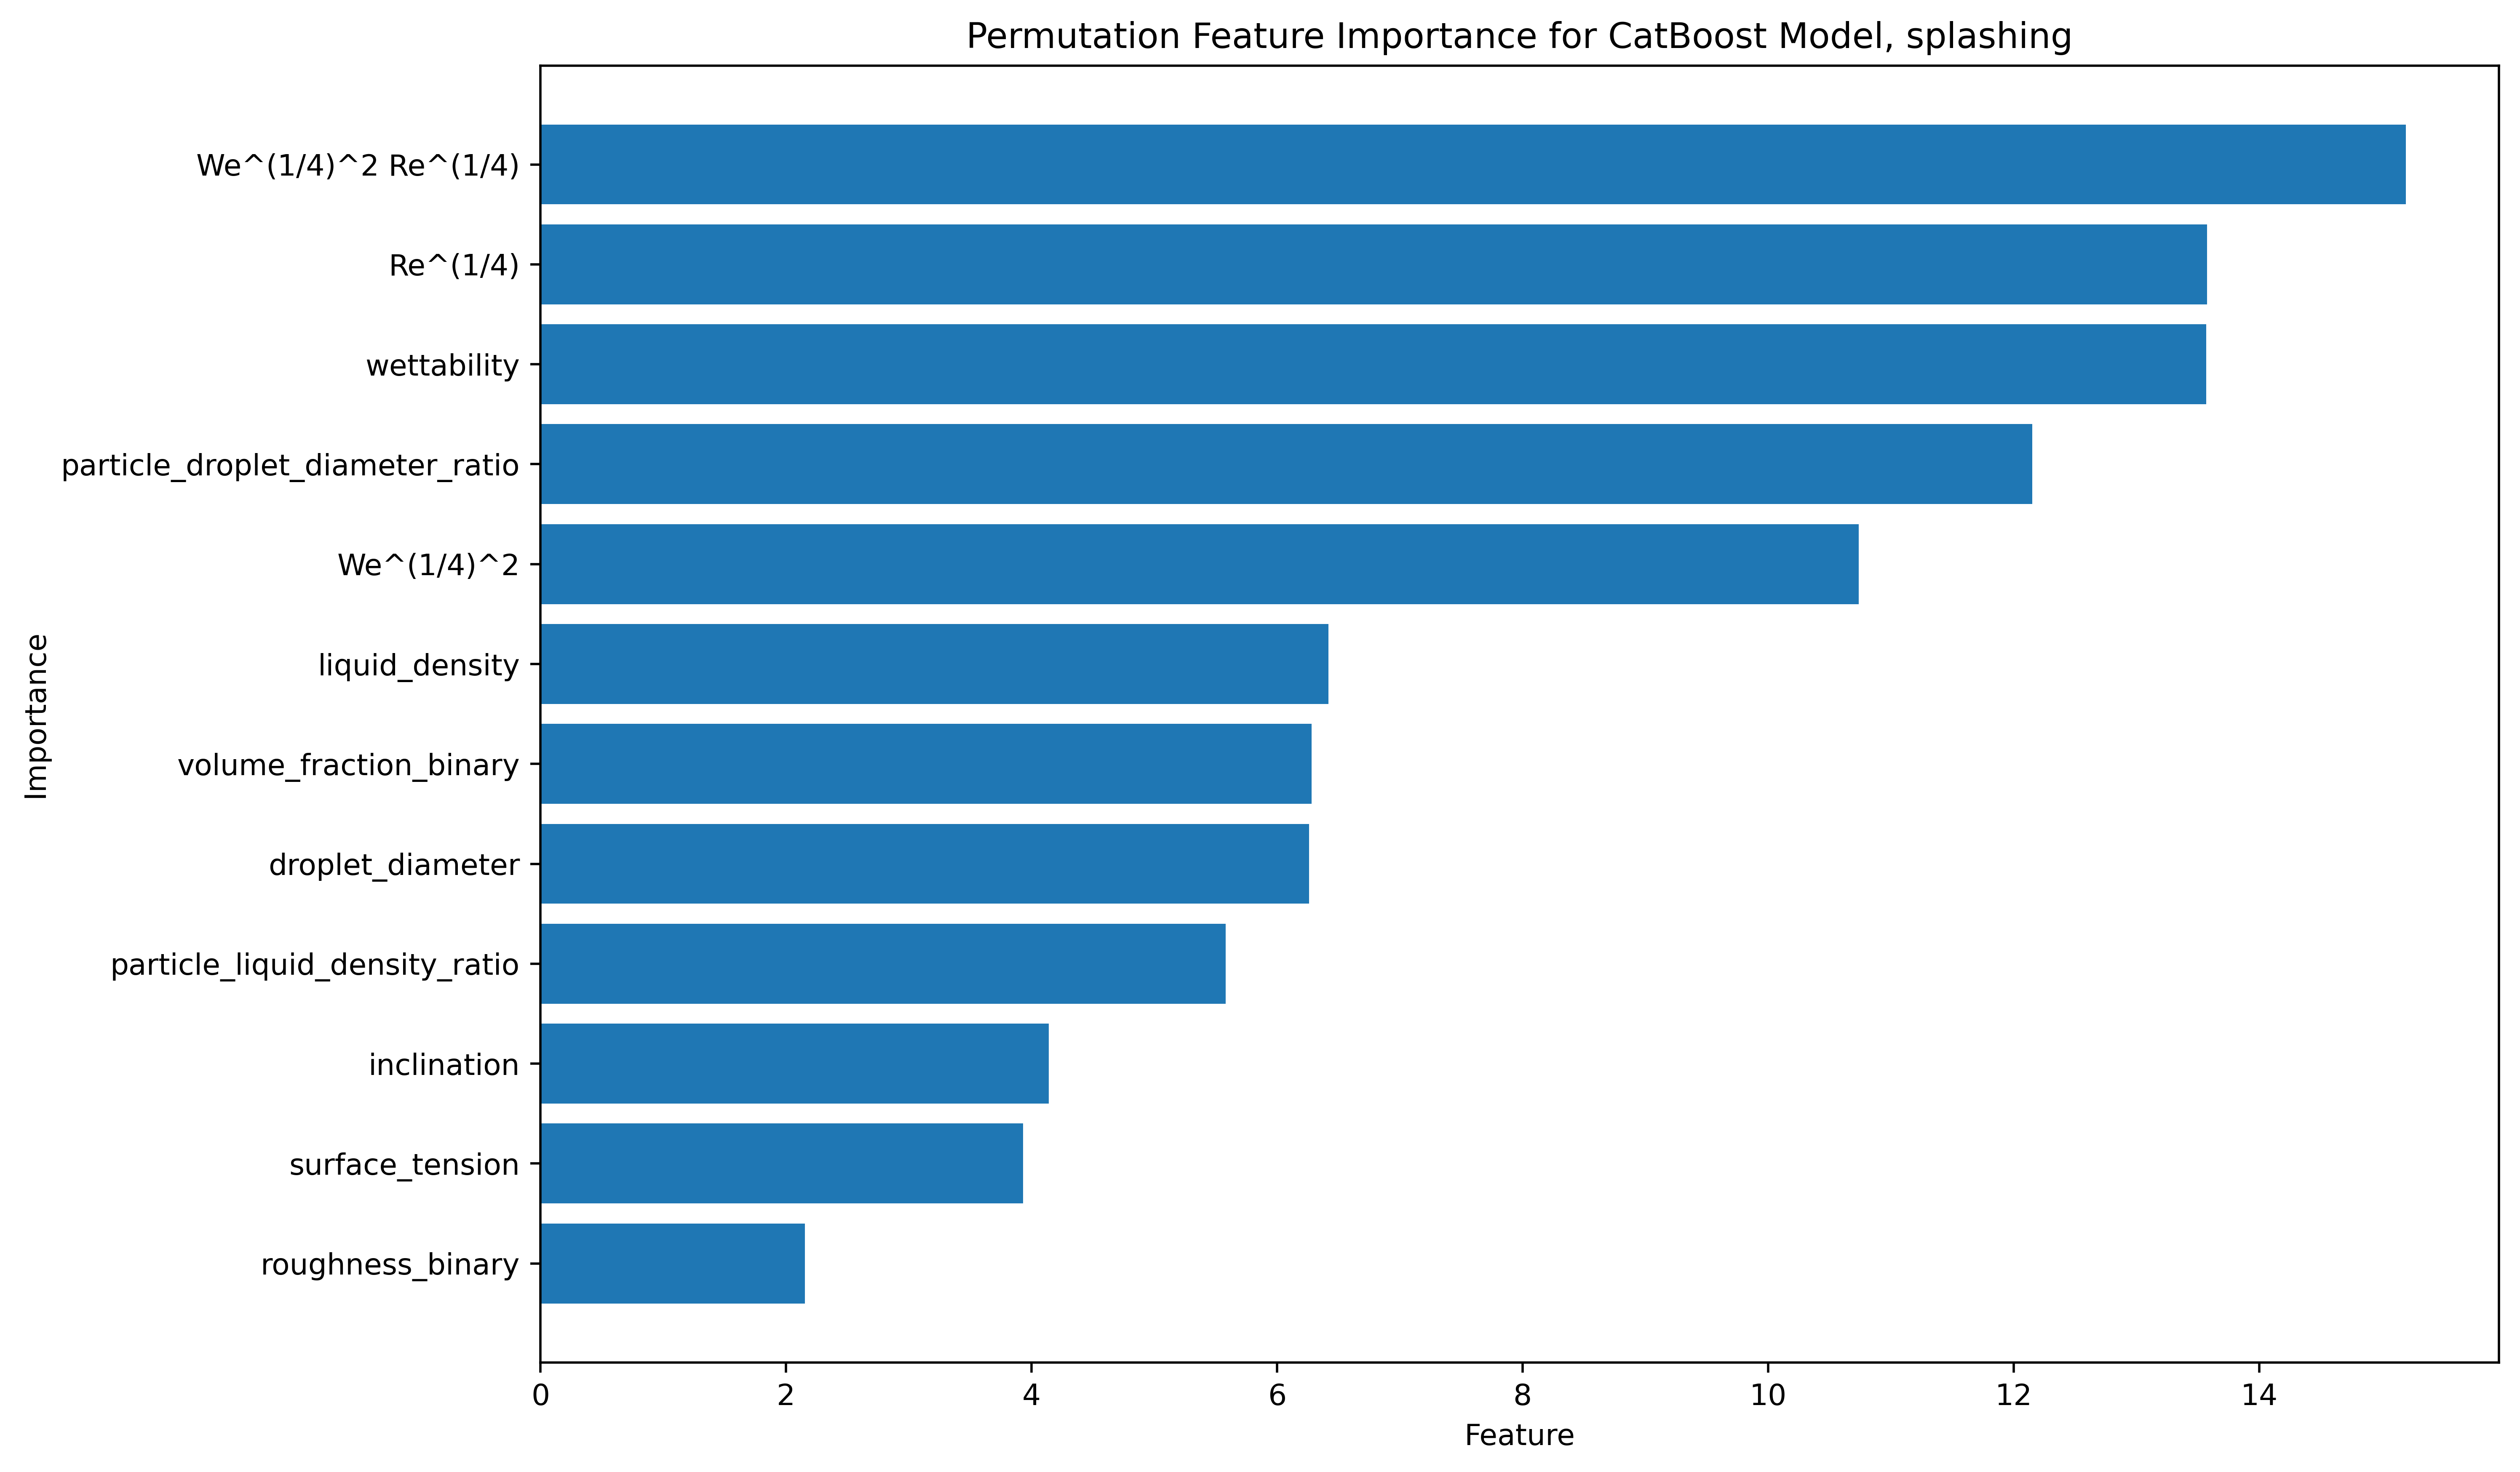

In [24]:
importances = pipeline.steps[0][1].feature_importances_
feature_names = pipeline.steps[0][1].feature_names_

df_permut_feature_importance = pd.DataFrame(
    {'Feature name': feature_names, 
     'Feature importance': importances}
).sort_values(by='Feature importance')
plt.figure(figsize=(12, 8),dpi=500)
plt.barh(
    y=df_permut_feature_importance['Feature name'],
    width=df_permut_feature_importance['Feature importance'])
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title(f'Permutation Feature Importance for CatBoost Model, {target}')
plt.savefig(path_interpretations / f'best_boosting_{target}.pdf', bbox_inches = 'tight')
plt.show()

In [25]:
target = 'splashing'
train, test = get_train_test(
    dataset_filename=dict_best_models[target]['boosting']['dataset'],
    target=target)
test = test[feature_names+[target]]

In [26]:
explainer = shap.TreeExplainer(pipeline.steps[0][1])
shap_values = explainer.shap_values(test.drop(columns=[target]))
plt.figure(figsize=(12, 8),dpi=500)
shap.summary_plot(shap_values, test.drop(columns=[target]), show=False)
plt.savefig(path_interpretations / f'best_boosting_{target}_shap.pdf', dpi=500, bbox_inches='tight')
plt.close()
# plt.show()

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


## Net impact

### Sklearn

In [27]:
target = 'net_impact'
train, test = get_train_test(
    dataset_filename=dict_best_models[target]['sklearn']['dataset'],
    target=target)
train = train[dict_num_features[dict_best_models[target]['sklearn']['dataset']]+['wettability']+[target]]
test = test[dict_num_features[dict_best_models[target]['sklearn']['dataset']]+['wettability']+[target]]

In [28]:
dict_best_models[target]['sklearn']

dataset         df_modelling_no_multicollinearity_pf
target                                    net_impact
model         kneighborsclassifier_net_impact_onehot
accuracy                                    0.946667
f1                                               0.9
precision                                        0.9
recall                                           0.9
roc_auc                                     0.931818
optuna_flg                                       1.0
Name: 38, dtype: object

In [29]:
path_pipeline = r'..\results\best_models_modelling_2\kneighborsclassifier_net_impact_onehot_df_modelling_no_multicollinearity_pf_net_impact.pkl'
pipeline = joblib.load(path_pipeline)

In [30]:
shutil.copy(path_pipeline, path_best_models / 'net_impact_sklearn.pkl')

WindowsPath('../results/best_models_selected_modelling_2/net_impact_sklearn.pkl')

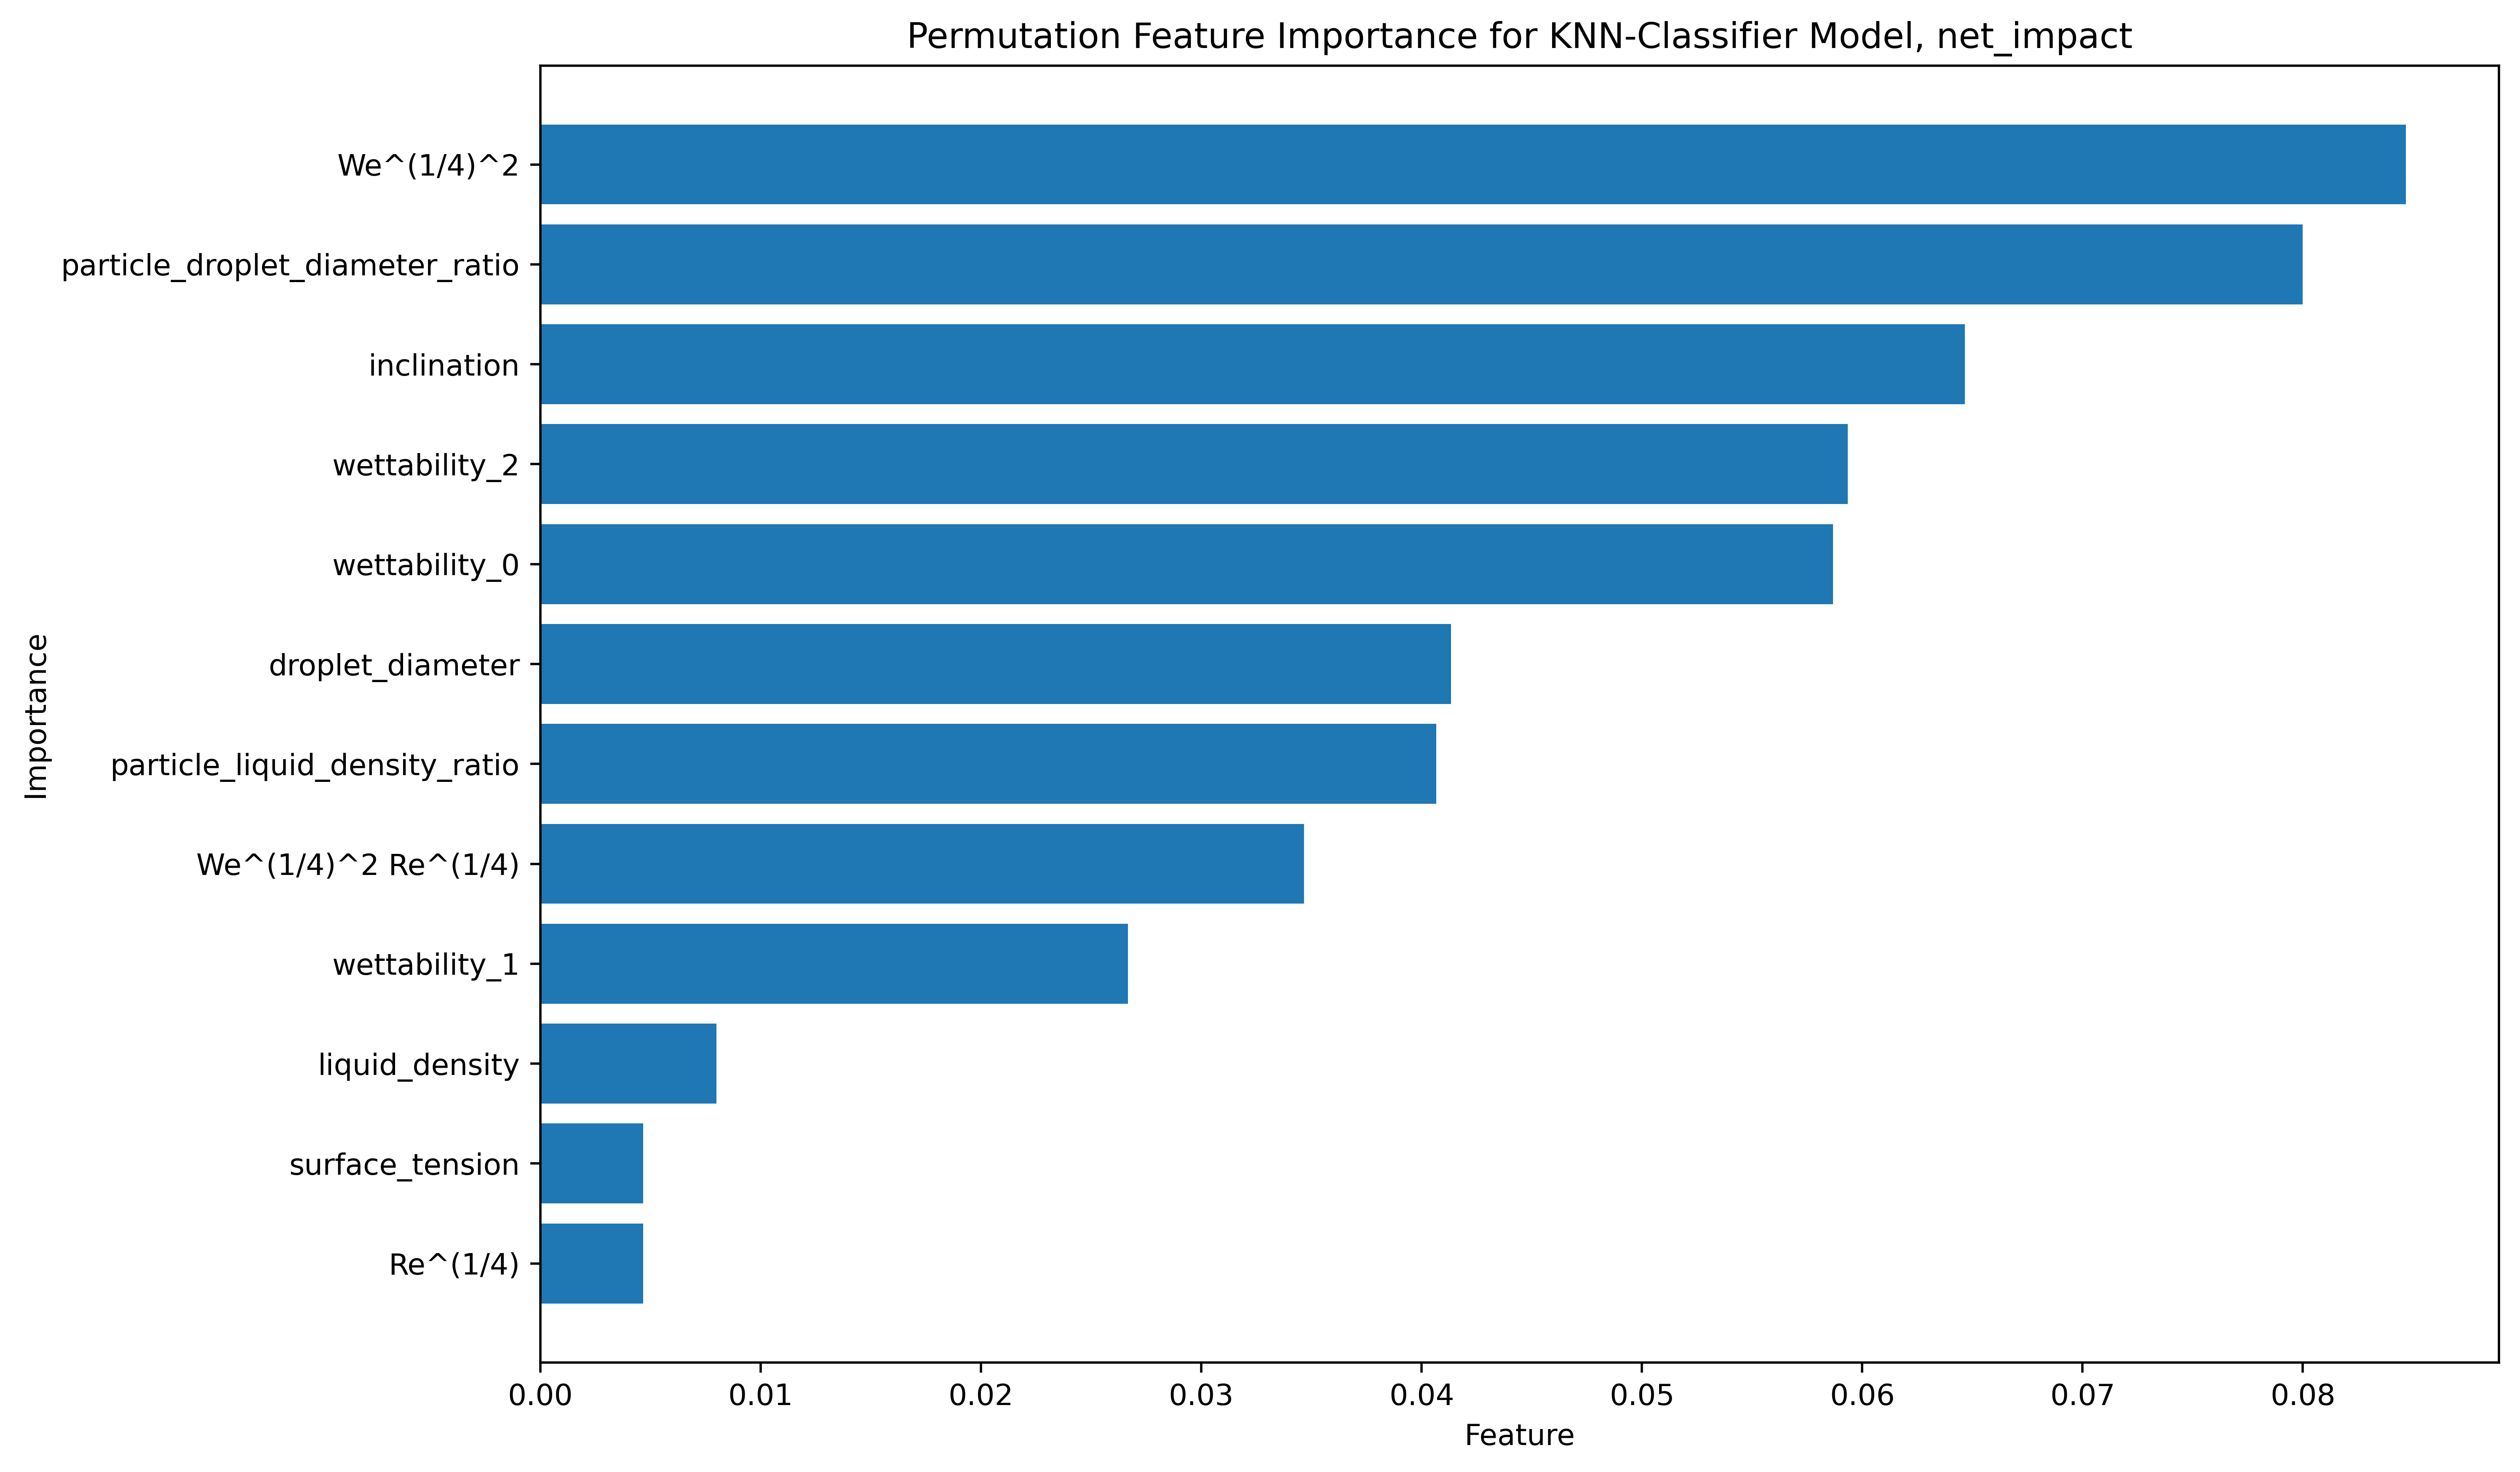

In [31]:
column_transformer = pipeline.steps[0][1].fit(train.drop(columns=[target]))
result = permutation_importance(
    estimator=pipeline.steps[1][1], 
    X=column_transformer.transform(test.drop(columns=[target])), 
    y=test[target], 
    n_repeats=20, 
    random_state=RANDOM_STATE)

importances = result.importances_mean
feature_names = column_transformer.get_feature_names_out()
feature_names = [x.split('__')[1] for x in feature_names]

df_permut_feature_importance = pd.DataFrame(
    {'Feature name': feature_names, 
     'Feature importance': importances}
).sort_values(by='Feature importance')
plt.figure(figsize=(12, 8),dpi=500)
plt.barh(
    y=df_permut_feature_importance['Feature name'],
    width=df_permut_feature_importance['Feature importance']
    )
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title(f'Permutation Feature Importance for KNN-Classifier Model, {target}')
plt.savefig(path_interpretations / f'best_sklearn_{target}.pdf', bbox_inches = 'tight')
plt.show()

### Boosting models

In [32]:
dict_best_models[target]['boosting']

dataset          df_modelling_dimensionless
target                           net_impact
model         catboostclassifier_net_impact
accuracy                           0.946667
f1                                      0.9
precision                               0.9
recall                                  0.9
roc_auc                            0.931818
optuna_flg                              NaN
Name: 0, dtype: object

In [33]:
path_pipeline = r'..\results\best_models_modelling_2\catboostclassifier_net_impact_df_modelling_dimensionless_net_impact.pkl'
pipeline = joblib.load(path_pipeline)

In [34]:
shutil.copy(path_pipeline, path_best_models / 'net_impact_boosting.pkl')

WindowsPath('../results/best_models_selected_modelling_2/net_impact_boosting.pkl')

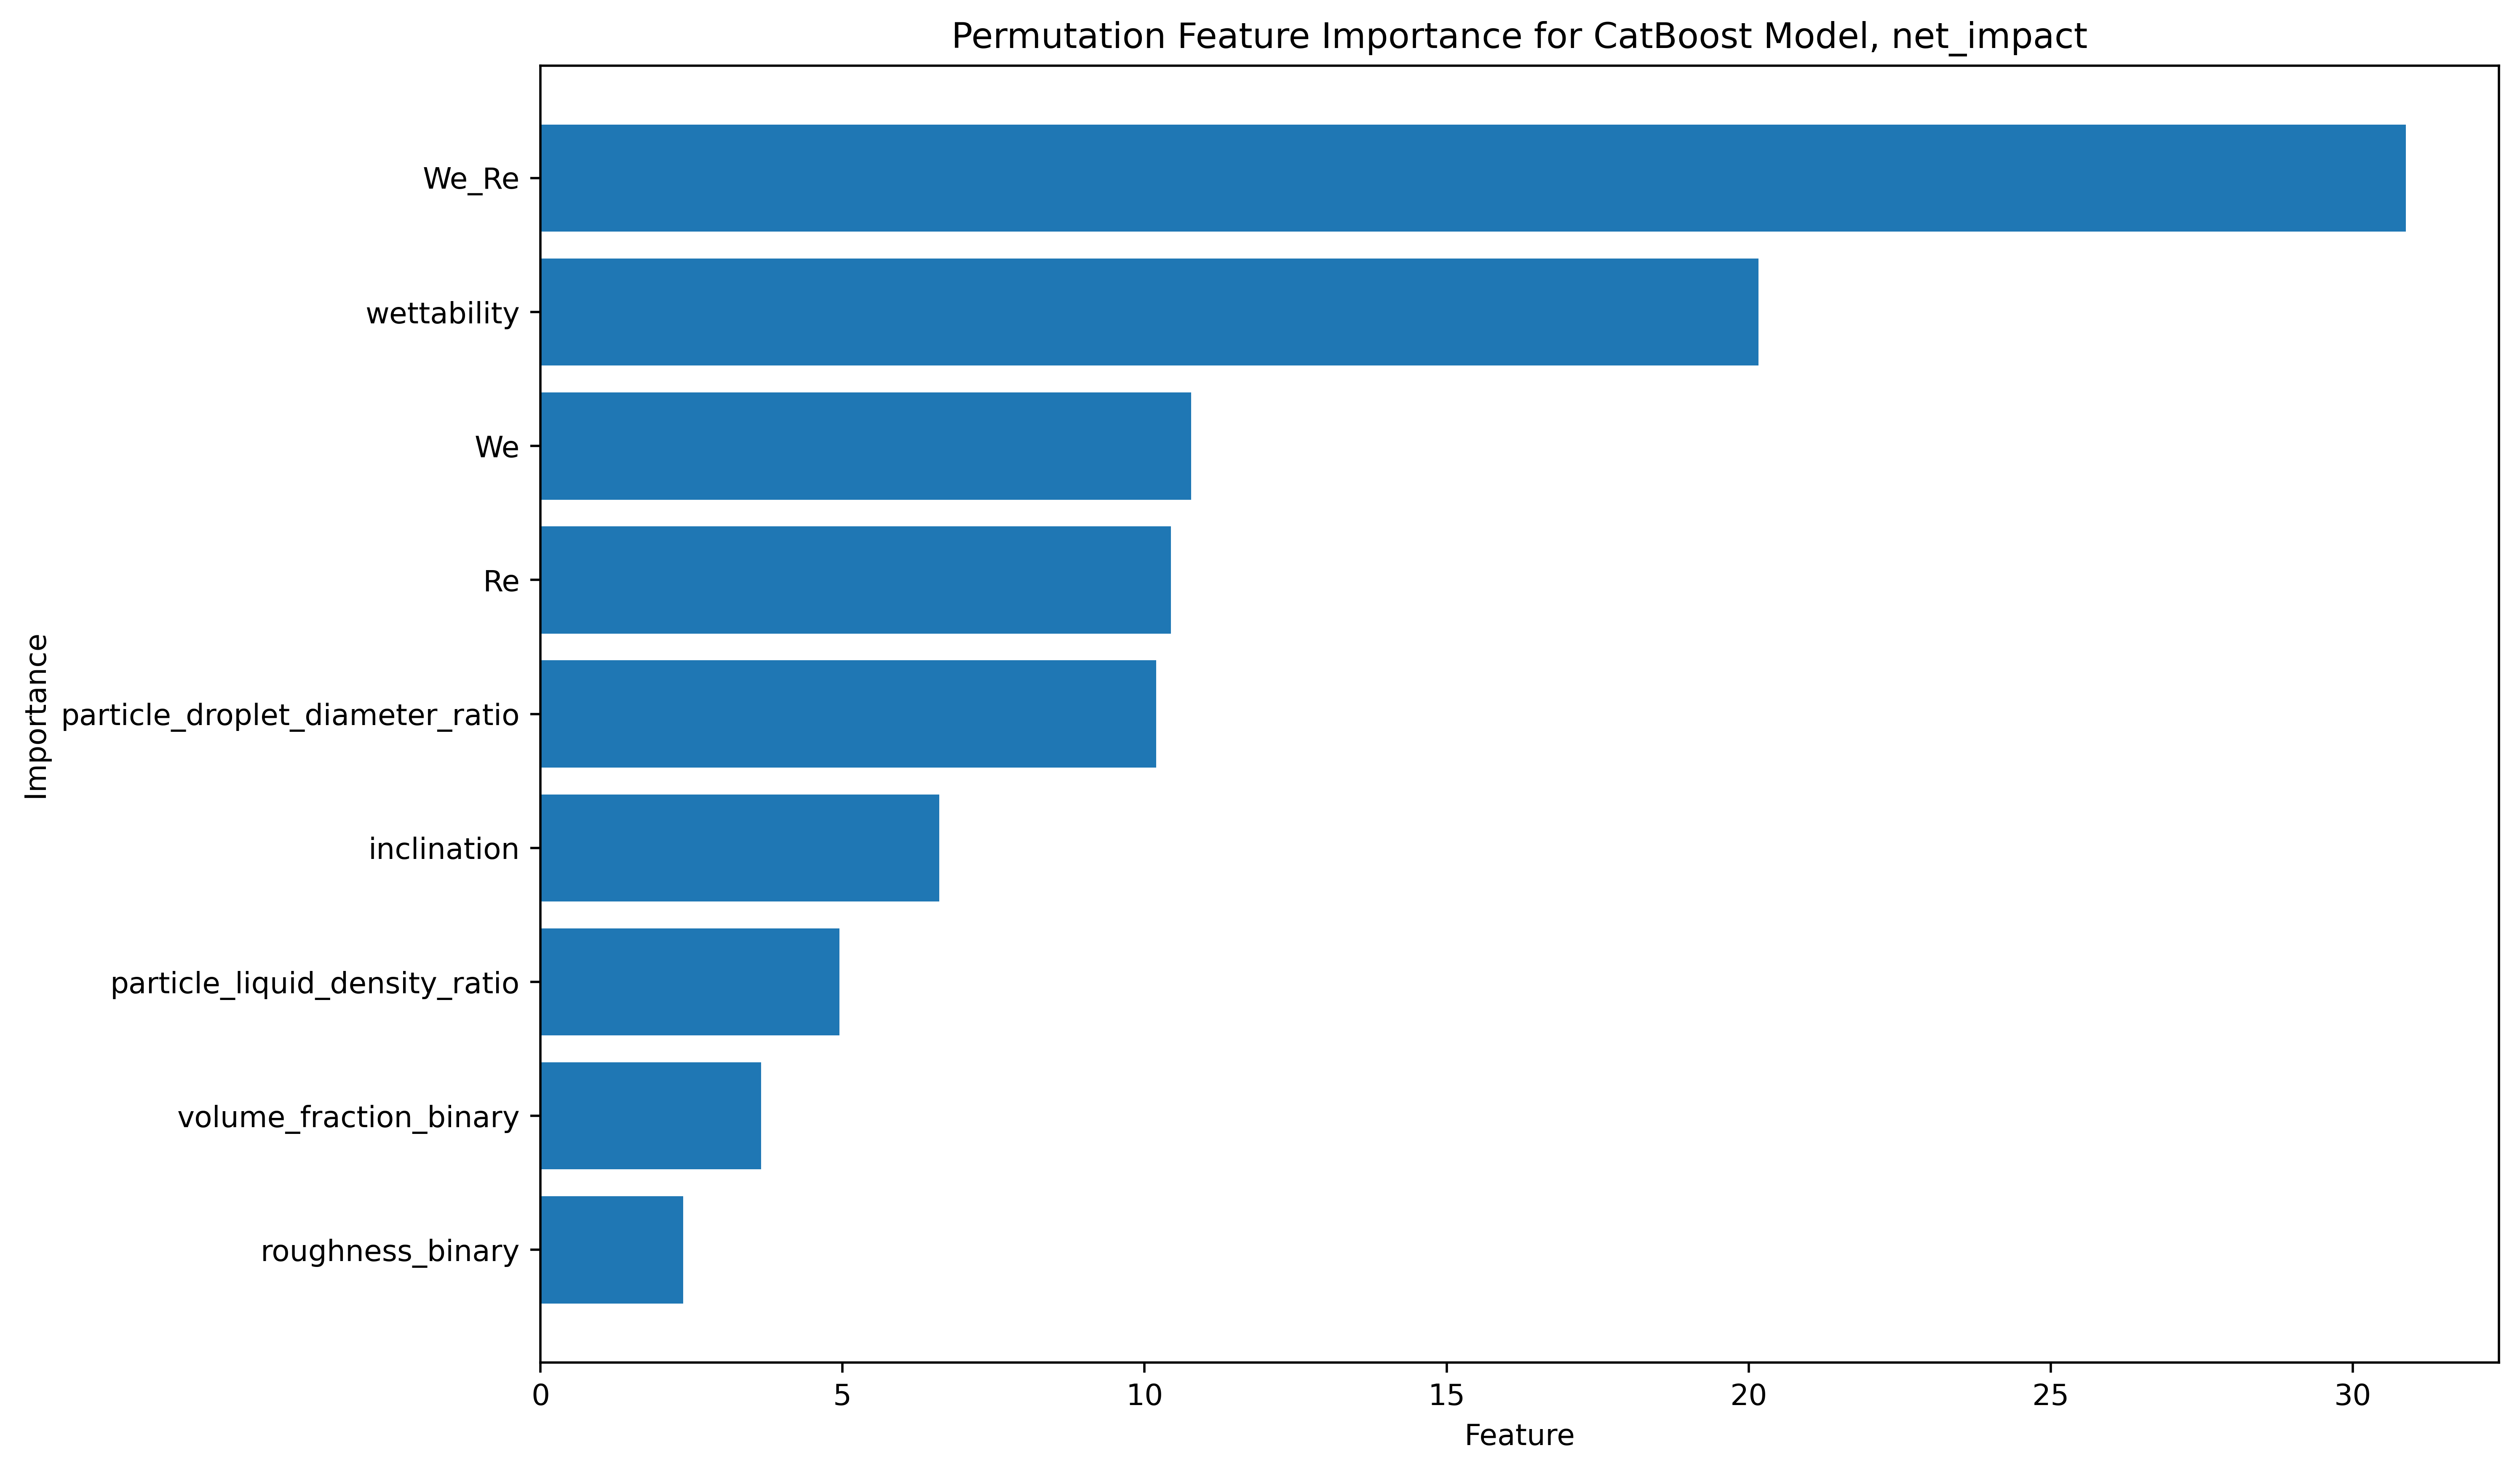

In [35]:
importances = pipeline.steps[0][1].feature_importances_
feature_names = pipeline.steps[0][1].feature_names_

df_permut_feature_importance = pd.DataFrame(
    {'Feature name': feature_names, 
     'Feature importance': importances}
).sort_values(by='Feature importance')
plt.figure(figsize=(12, 8),dpi=500)
plt.barh(
    y=df_permut_feature_importance['Feature name'],
    width=df_permut_feature_importance['Feature importance'])
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title(f'Permutation Feature Importance for CatBoost Model, {target}')
plt.savefig(path_interpretations / f'best_boosting_{target}.pdf', bbox_inches = 'tight')
plt.show()

In [36]:
target = 'net_impact'
train, test = get_train_test(
    dataset_filename=dict_best_models[target]['boosting']['dataset'],
    target=target)
test = test[feature_names+[target]]

In [37]:
explainer = shap.TreeExplainer(pipeline.steps[0][1])
shap_values = explainer.shap_values(test.drop(columns=[target]))
plt.figure(figsize=(12, 8), dpi=500)
shap.summary_plot(shap_values, test.drop(columns=[target]), show=False)
plt.savefig(path_interpretations / f'best_boosting_{target}_shap.pdf', dpi=500, bbox_inches='tight')
plt.close()
# plt.show()

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
